In [31]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("../Src"))

from lcg import lcg


## Generation of Uniform Samples Using a Linear Congruential Generator

In this first experiment, we use a linear congruential generator (LCG) to produce pseudo-random numbers. The LCG is a deterministic algorithm defined by a recurrence relation that generates a sequence of values which approximate a uniform distribution on the interval $(0,1)$.

Starting from an initial seed, the generator produces a sequence of numbers that, although not truly random, exhibit statistical properties similar to independent uniform random variables.

To evaluate the quality of the generator, we generate samples of increasing size $n$ and represent them using histograms. As $n$ grows, we expect the empirical distribution of the generated values to approach the theoretical uniform distribution.



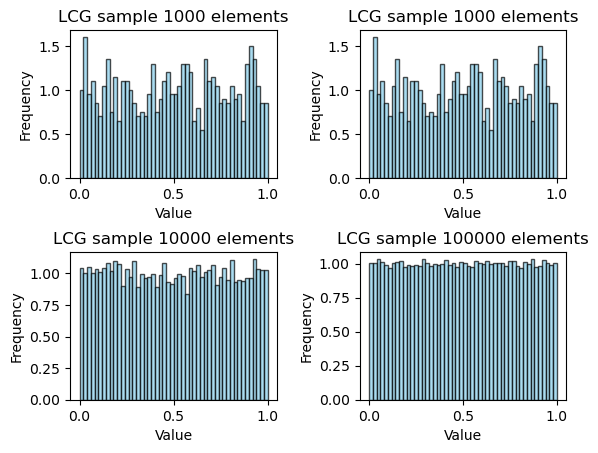

In [32]:
n=[1000,1000,10000,100000]

for i in range(len(n)):
    plt.subplot(2,2,i+1)
    samples = lcg(n[i], seed=1, a=1664525, m=2**32)
    plt.subplots_adjust(hspace=0.5, wspace=0.4)
    plt.hist(samples, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title(f"LCG sample {n[i]} elements")
    plt.xlabel('Value')
    plt.ylabel('Frequency')

It is clearly shown that as n tends to infinity, the sample approaches a uniform distribution.

## Generation of Non-Uniform Distributions

It is well known that pseudo-random number generators such as the linear congruential generator (LCG) produce samples that approximate a uniform distribution on the interval $(0,1)$ as the sample size increases. However, many practical applications require sampling from non-uniform distributions.

A general method to achieve this is the *inverse transform method*. Starting from a uniform random variable $U \sim \text{Uniform}(0,1)$, we can generate a new random variable $X$ with a desired distribution by applying the inverse of its cumulative distribution function (CDF):

$$
X = F^{-1}(U)
$$

As an example, consider the exponential distribution with parameter $\lambda$. Its cumulative distribution function is given by:

$$
F(x) = 1 - e^{-\lambda x}, \quad x \geq 0
$$

By inverting this expression, we obtain:

$$
X = -\frac{1}{\lambda} \ln(1 - U)
$$

This transformation allows us to generate exponentially distributed samples from uniformly distributed ones. In practice, we first generate a sample using the LCG and then apply this transformation element-wise.

Finally, we can validate the method by comparing the histogram of the transformed sample with the analytical probability density function of the exponential distribution. 

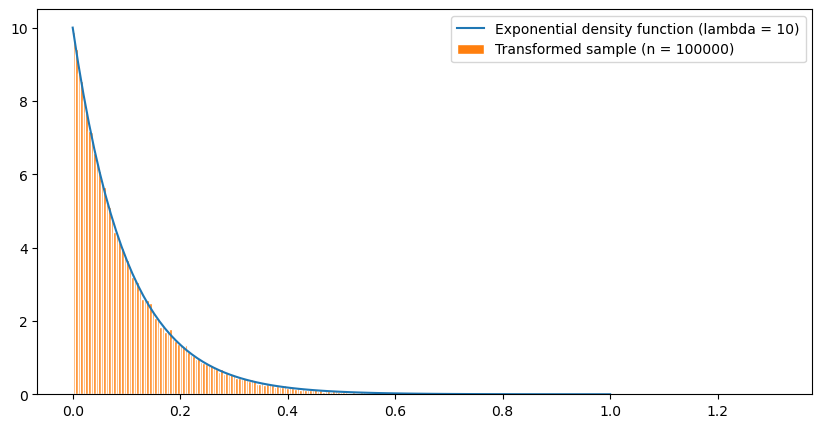

In [33]:
# Generate the uniform sample
x = np.linspace(0,1,100)  
lambda_ = 10  # exponential parameter
f_x = lambda_ * np.exp(-lambda_ * x)

uniform_sample = lcg(n=100000, seed=1, a=1664525, m=2**32)
new_sample = -np.log(1 - uniform_sample) / lambda_

plt.figure(figsize=(10,5))
plt.plot(x, f_x, label='Exponential density function (lambda = 10)')
plt.hist(new_sample, density=True, edgecolor='white', bins='auto',label='Transformed sample (n = 100000)')
plt.legend()
plt.show()